## Sensitivity analysis of Otsu thresholding:
**Doing necessary imports:**

In [2]:
# Imports:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.net import attrs as a
from sunpy.net import Fido
from sunpy.coordinates import HeliographicStonyhurst
import astropy.units as u
from astropy.coordinates import SkyCoord

from suitcolormap import suit_cmap, suit_norm
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

**Importing raw fits file and the flat-field corrected, percentile normalized and disk masked array.** 

In [3]:
suit_map = sunpy.map.Map(r"..\Data\Raw\SUT_T26_0649_002132_Lev1.0_2026-05-09T07.09.21.400_08B2NB03.fits")
arr_2d_masked = np.load(r"..\Data\Processed\arr_2d_masked.npy")  # This is the same array on which otsu thresholding was done.

**Looping:**

In [4]:
threshold_list = np.arange(0.40,0.66,0.05)   # Creating a list of different threshold values 
print(threshold_list)

[0.4  0.45 0.5  0.55 0.6  0.65]


In [5]:
for threshold_value in threshold_list:
    active_region_mask = arr_2d_masked > threshold_value
    labeled = label(active_region_mask)
    labeled_regions = regionprops(labeled)
    areas = [r.area for r in labeled_regions]
    print(f"Threshold {threshold_value:.2f}: min area = {min(areas)}, max area = {max(areas)}, num blobs = {len(areas)}")

Threshold 0.40: min area = 1.0, max area = 1407909.0, num blobs = 1758
Threshold 0.45: min area = 1.0, max area = 1187582.0, num blobs = 4067
Threshold 0.50: min area = 1.0, max area = 187937.0, num blobs = 11502
Threshold 0.55: min area = 1.0, max area = 83570.0, num blobs = 4959
Threshold 0.60: min area = 1.0, max area = 39607.0, num blobs = 2556
Threshold 0.65: min area = 1.0, max area = 5211.0, num blobs = 2044


From the above results we can see that our approach in the original pipeline of assigning a hardcode area (10,000) is not useful here, we need to improvise as per the different threshold values. So, we will implement 99th percentile cutoff.

2026-08-04 16:25:03 - sunpy - WARNING: SunpyUserWarning: The conversion of these 2D helioprojective coordinates to 3D is all NaNs because off-disk coordinates need an additional assumption to be mapped to calculate distance from the observer. Consider using the context manager `SphericalScreen()`.
 '2026-05-09T00:00:00.000' '2026-05-09T00:00:00.000'
 '2026-05-09T00:00:00.000' '2026-05-09T00:00:00.000'
 '2026-05-09T00:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000'], rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-09T07:09:21.400, rsu

Threshold 0.40: 1397 blobs, 6 unique NOAA ARs -> {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14429), np.int32(14431)}
Threshold 0.45: 3680 blobs, 7 unique NOAA ARs -> {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14436), np.int32(14429), np.int32(14431)}
Threshold 0.50: 11037 blobs, 6 unique NOAA ARs -> {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14429), np.int32(14431)}
Threshold 0.55: 4565 blobs, 6 unique NOAA ARs -> {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14429), np.int32(14431)}
Threshold 0.60: 2178 blobs, 6 unique NOAA ARs -> {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14429), np.int32(14431)}
Threshold 0.65: 1669 blobs, 5 unique NOAA ARs -> {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14431)}


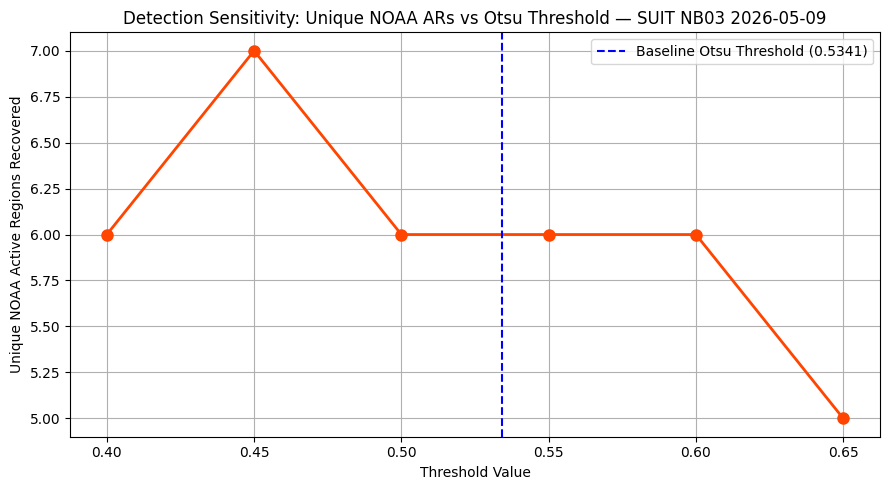

In [6]:
# HEK quey needs not be run multiple times in the loop because the result is independent of the images or the threshold values that we are working on.
tstart = '2026/05/09 01:09:21'
tend = '2026/05/09 13:09:21'
event_type = 'AR'
result = Fido.search(a.Time(tstart, tend), a.hek.EventType(event_type))
noaa_catalog = result[0][result[0]['ar_noaanum'].filled(0) != 0]


results = []  # This will hold (threshold_value, num_unique_ARs, verified_regions)

for threshold_value in threshold_list:

    # 1. Thresholding-
    active_region_mask = arr_2d_masked > threshold_value

    # 2. Label blobs-
    labeled = label(active_region_mask)
    labeled_regions = regionprops(labeled)
    areas = [r.area for r in labeled_regions]

    # 3. We will now try to remove abnormally large blobs using 99th percentile cutoff-
    area_cutoff = np.percentile(areas, 99)
    bad_labels = [r.label for r in labeled_regions if r.area >= area_cutoff]
    updated_labels = np.isin(labeled, bad_labels)
    solar_limb_removed = active_region_mask & (~updated_labels)

    # 4. Now we will try to minimize the off-distortion present in the masked image-
    off_disk_masked = np.zeros(active_region_mask.shape, dtype=bool)
    off_disk_masked[1290:1400, 1010:1150] = True
    off_disk_removed = solar_limb_removed & (~off_disk_masked)
    cleaned_labeled = label(off_disk_removed)
    regions = regionprops(cleaned_labeled)

    # 5. Validation-
    verified_regions = []
    for i in regions:
        x, y = i.centroid
        hpc_coord = suit_map.pixel_to_world(y * u.pixel, x * u.pixel)    #converting pixel coordinates to helioprojective coordinates
        hgs_coord = hpc_coord.transform_to(HeliographicStonyhurst)       # converting HGC to heliographic stonyhurst coordinates
        catalog_comparison = hgs_coord.separation(noaa_catalog['hgs_coord'])
        best_match_idx = np.argmin(catalog_comparison)
        if np.any(catalog_comparison <= 5 * u.deg):                  # Applying comparison between our image and NOAA database
            verified_regions.append((i.label, noaa_catalog['ar_noaanum'][best_match_idx]))

    unique_noaa = set([t[1] for t in verified_regions])
    num_unique_ARs = len(unique_noaa)

    results.append((threshold_value, num_unique_ARs, unique_noaa))
    print(f"Threshold {threshold_value:.2f}: {len(regions)} blobs, {num_unique_ARs} unique NOAA ARs -> {unique_noaa}")

# Visualization: We will now plot the graph of the unique NOAA ARs detected for each threshold value along with a line that shows our Otsu threshold-
thresholds_plot = [r[0] for r in results]
counts_plot = [r[1] for r in results]

plt.figure(figsize=(9, 5))
plt.plot(thresholds_plot, counts_plot, marker='o', color='orangered', linewidth=2, markersize=8)
plt.axvline(0.5341, color='blue', linestyle='--', label='Baseline Otsu Threshold (0.5341)')   # Otsu threshold line
plt.xlabel('Threshold Value')
plt.ylabel('Unique NOAA Active Regions Recovered')
plt.title('Detection Sensitivity: Unique NOAA ARs vs Otsu Threshold — SUIT NB03 2026-05-09')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Outputs/Figures/Fig_Part3_Sensitivity_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()